<h1><center>Сегментация изображений</center></h1>

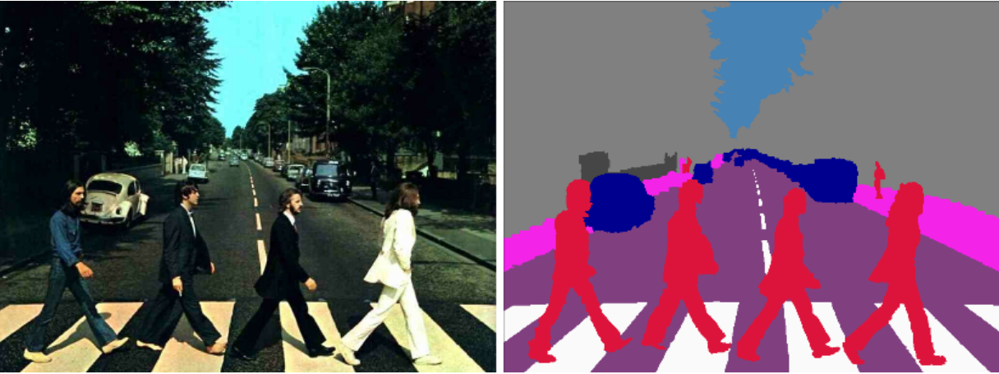

## Сегментация изображений

**Сегментация** — это задача компьютерного зрения, в которой каждому пикселю изображения присваивается метка класса. В отличие от классической классификации (где всему изображению соответствует одна метка), сегментация работает на уровне отдельных пикселей, обеспечивая **попиксельную классификацию**.

Существует два основных типа сегментации:

### 1. Семантическая сегментация  
Каждому пикселю изображения присваивается метка, соответствующая его семантическому классу (например, «дорога», «автомобиль», «человек»). При этом все объекты одного и того же класса рассматриваются **как единое целое**, без различия между отдельными экземплярами.

> **Пример**: если на изображении находятся два автомобиля, семантическая сегментация пометит все их пиксели как «автомобиль», но не будет различать, где заканчивается один и начинается другой.

### 2. Инстанс-сегментация  
Этот подход также присваивает метки пикселям, но дополнительно **разделяет объекты одного класса на отдельные инстансы** (экземпляры). То есть каждый объект получает уникальную идентификацию даже при принадлежности к одному и тому же классу.

> **Пример**: два автомобиля на изображении будут не только распознаны как «автомобиль», но и обособлены друг от друга — каждый получит свою маску сегментации.

---

### 🔍 Сравнение

| Тип сегментации          | Различает экземпляры? | Уровень детализации |
|--------------------------|------------------------|----------------------|
| Семантическая            | ❌                     | По классам           |
| Инстанс-сегментация     | ✅                     | По объектам          |

---

Инстанс-сегментация является более сложной задачей, поскольку требует не только классификации пикселей, но и выделения отдельных объектов, их локализации и уникальной идентификации.


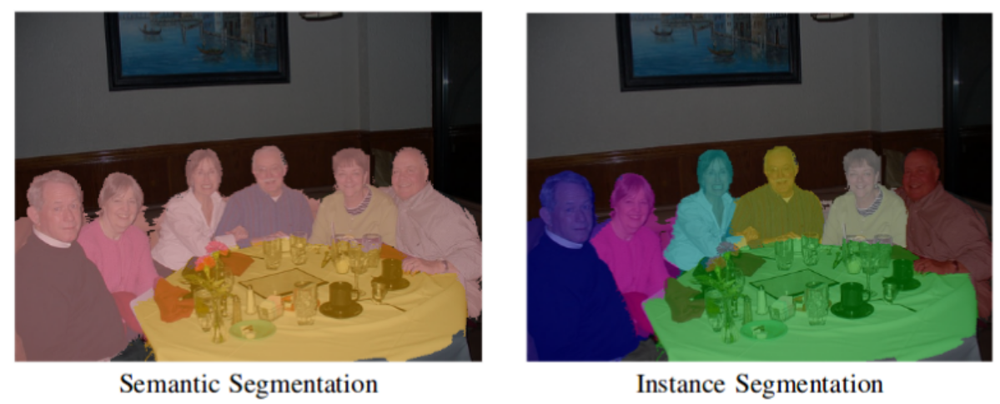

Для тренировки нейронных сетей решающих задачу сегментирования применяются свои специальные датасеты, в которых размечена маска изображения, например, такие как

- **PASCAL VOC** ([PASCAL Visual Object Classes](http://host.robots.ox.ac.uk/pascal/VOC/))  
- **COCO** ([Common Objects in Context](https://cocodataset.org/))

Датасетов для сегментации меньше и они сложнее в составлении. Поэтому существует распространенная практика использования предобученнной нейронной сети, например, на ImageNet, в качестве части отвественной за восприятие объектов. Затем уже нейронная сеть доубучается на размеченных масках с помощью специальных датасетов.

Иногда маски не хранят в растровом представлении, а используют маску в закодированном в последовательность виде, к примеру,

- **RLE (run-length encoding, кодирование длин серий)**

— алгоритм сжатия данных, заменяющий повторяющиеся символы (серии) на один символ и число его повторов. Серией называется последовательность, состоящая из нескольких одинаковых символов.

> **Пример**:  
> Исходная последовательность пикселей (1D для простоты):  
> `0 0 0 1 1 1 1 0 0 1 1`  
>  
> В RLE-кодировке она может быть представлена как:  
> `(3, 0), (4, 1), (2, 0), (2, 1)`  
> или, в случае бинарной маски (где 0 = фон), часто хранят только позиции и длины серий с `1`:  
> `4 4 10 2` — где каждая пара `(start, length)` описывает начало и длину объектной области.

In [1]:
def rle_decode(mask_rle, shape=(1080, 512, 1)):
    """
    mask_rle: run-length as string formated (start length)
    shape: (height,width) of array to return
    Returns numpy array, 1 - mask, 0 - background
    """
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    s = mask_rle.split()
    print(s)
    print(s[0:][::2], s[1:][::2])
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]

    starts -= 1

    ends = starts + lengths

    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    img = img.reshape(shape)
    return img

['3', '4', '10', '1', '15', '1', '17', '1', '24', '1', '33', '8']
['3', '10', '15', '17', '24', '33'] ['4', '1', '1', '1', '1', '8']


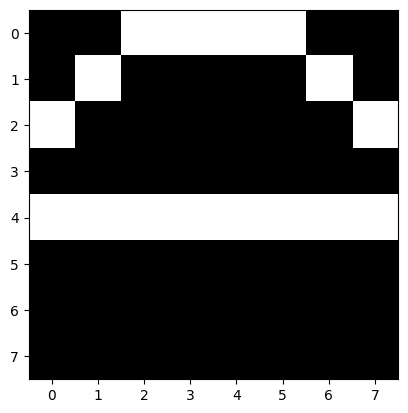

In [2]:
import numpy as np
import matplotlib.pyplot as plt


rle_string = "3 4 10 1 15 1 17 1 24 1 33 8"

mask = rle_decode(rle_string, shape=(8, 8))
plt.imshow(mask.reshape(8, 8), cmap="gray");

## слои для моделей сегментации



### Fully Convolutional Network

Одна из самых простых архитектур - это [FCN](https://towardsdatascience.com/review-fcn-semantic-segmentation-eb8c9b50d2d1) (Fully Convolutional Network). Это первая удачная попытка использования нейронной сети для задачи семантической сегментации. В этой архитектуре все слои сверточные. На выходе используется как правило один деконволюционный слой.
Одна из основных проблем - это низкое разрешение на выходе.


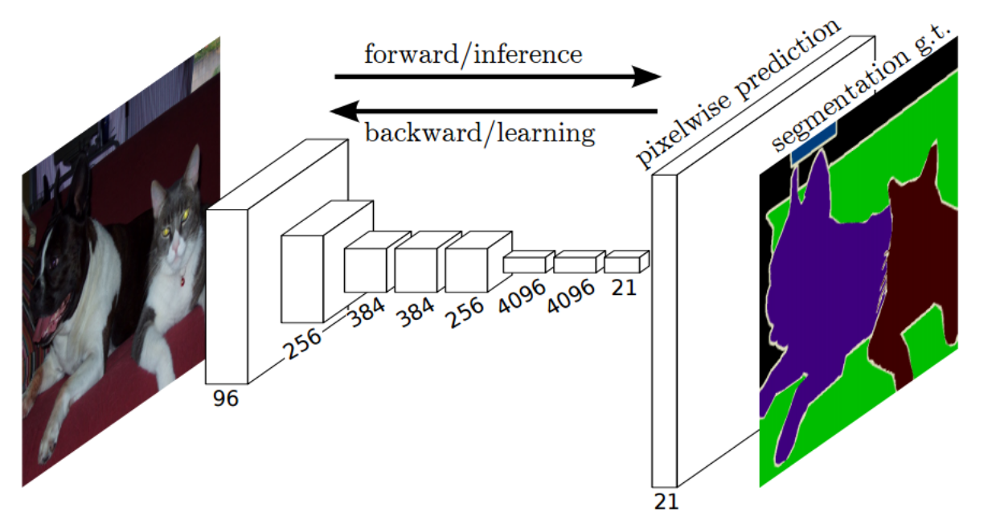

In [3]:
from torch import nn

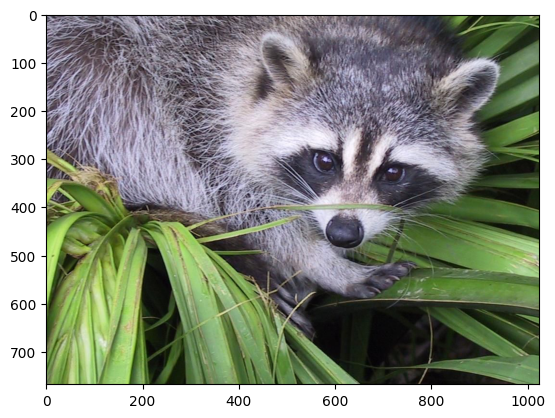

In [4]:
from scipy import datasets
import matplotlib.pyplot as plt

img = datasets.face()
plt.imshow(img);

(34, 34, 3)


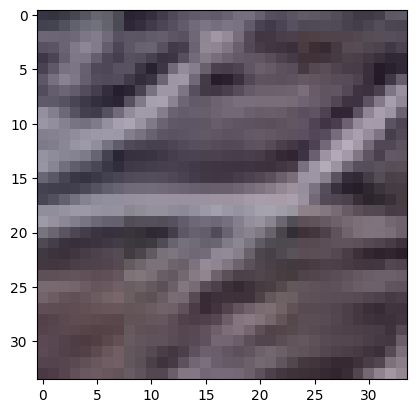

In [5]:
img = img[30:64, 40:74]
print(img.shape)
plt.imshow(img);

In [6]:
from torchvision.transforms import ToTensor

img_tensor = ToTensor()(img)
img_tensor.shape

D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


torch.Size([3, 34, 34])

## слой Upsample

визуализации работы слоев [https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md]
Слой UpSample- просто растягивает картинку. Параметры:

    scale_factor - "Во сколько раз увеличить"
        - scale_factor=2 - увеличить высоту и ширину в 2 раза
        - scale_factor=4 - увеличить в 4 раза

    size - "Какого размера хочу получить"

        - size=(64, 64) - хочу получить картинку точно 64x64 пикселей

        - Если задан size, scale_factor игнорируется

    mode - "Способ увеличения"

        - nearest - "ближайший сосед" - быстрый, но угловатый

        - bilinear - "плавное сглаживание" - медленнее, но качественнее

    align_corners - "Как выравнивать углы"

        - True - углы старой и новой картинки совпадают

        - False - углы могут немного сместиться


In [7]:
upsamle = nn.Upsample(
    scale_factor=(16, 16),
    mode="bilinear",
    #   mode='nearest',
)
# upsamle.weight

torch.Size([3, 544, 544])


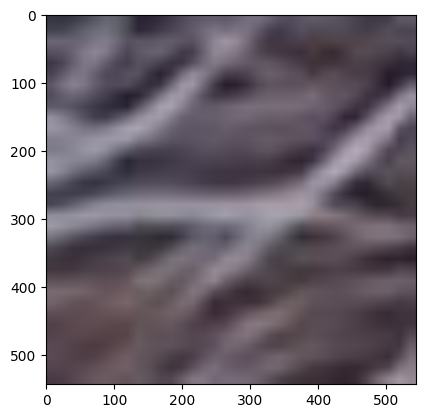

In [8]:
upsamled_img = upsamle(img_tensor[None])[0]
print(upsamled_img.shape)
plt.imshow(upsamled_img.permute(1, 2, 0));

## обратные свертки


ConvTranspose2d - "Умная сборка из кусочков":

    in_channels - "Сколько каналов на входе"
    out_channels - "Сколько каналов на выходе"

    kernel_size - "Размер фильтра-ядра"

    stride - "Шаг применения ядра"

        - stride=1 - ядро движется по каждому пикселю

        - stride=2 - ядро перепрыгивает через 1 пиксель

        - Большой stride = большее увеличение размера

    padding - "Добавление рамки вокруг картинки"

        - padding=1 - добавляем рамку в 1 пиксель вокруг


    dilation - "Растянутый фильтр"

    dilation=2 - пропуски в применении ядра делают его больше


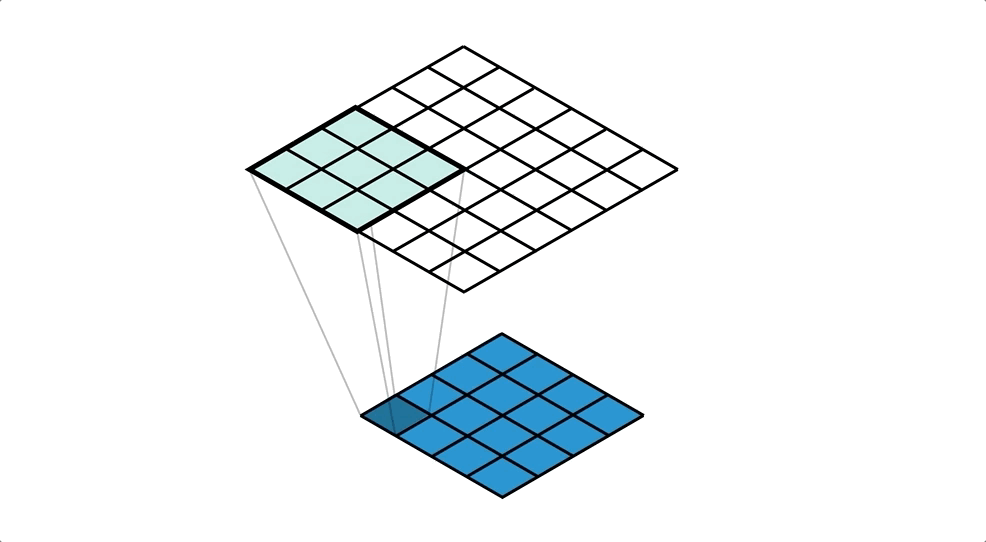

Применения ядра с шагом 1

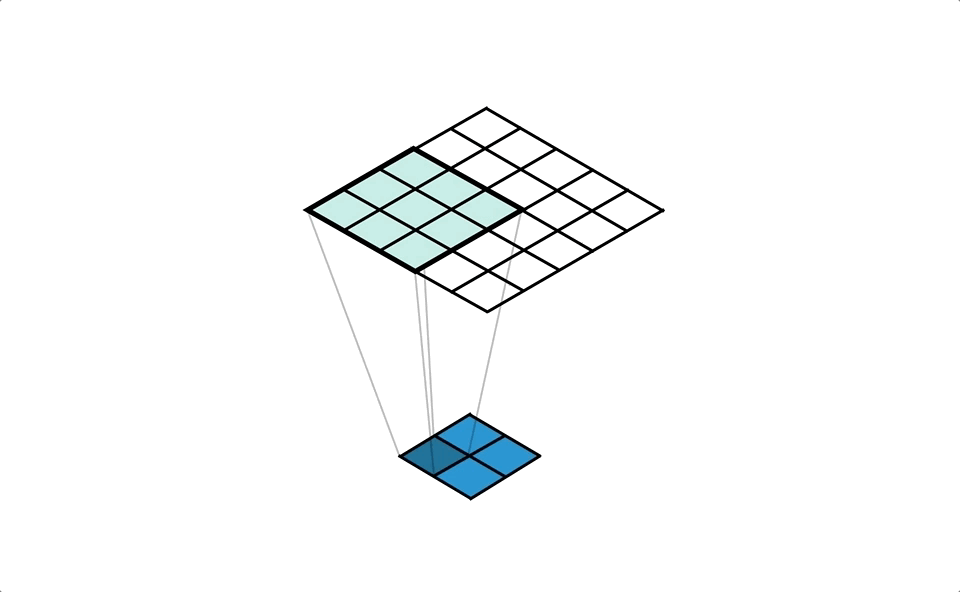

Применения ядра с шагом 2


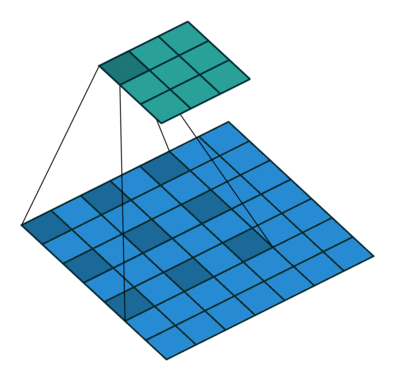

Применения ядра с dilation 2

In [9]:
conv = nn.ConvTranspose2d(in_channels=3, out_channels=3, stride=8, kernel_size=16)
conv.weight.shape

torch.Size([3, 3, 16, 16])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-34.27797..31.357038].


torch.Size([3, 280, 280])


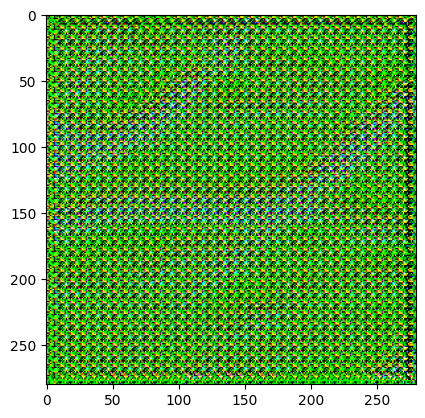

In [10]:
conv_img = conv(img_tensor[None])[0].detach().cpu()
print(conv_img.shape)
plt.imshow((conv_img.permute(1, 2, 0)* 255 ));

### SegNet

SegNet появилась в 2015 г. Данная архитектура состоит из конволюционной и деконволюционной части. Она отчасти повторяет собой архитектуру Autoencoder, где есть кодирующая и декодирующая часть.

Декодирующая часть в SegNet позволяет сделать более плавное разворачивание изображения после того как отработала сверточная часть архитектуры. Благодаря этому границы объектов на изображение определяются более корректно.

Стоит отметить, что в качестве сверточной части могут использоваться различные предтренерованные нейронные сети для решения задач классификации, например различные модификации VGG и ResNet.

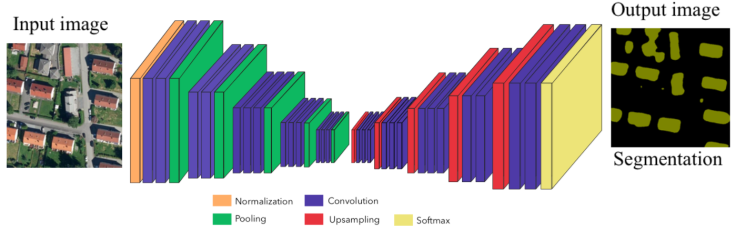

### Unet

Unet - это одна из базовых и наиболее используемых моделей для сегментации. Есть очень много имплементаций Unet, но давайте разберемся с оригинальной Unet.
Ее архитектура представлена на картинке ниже.



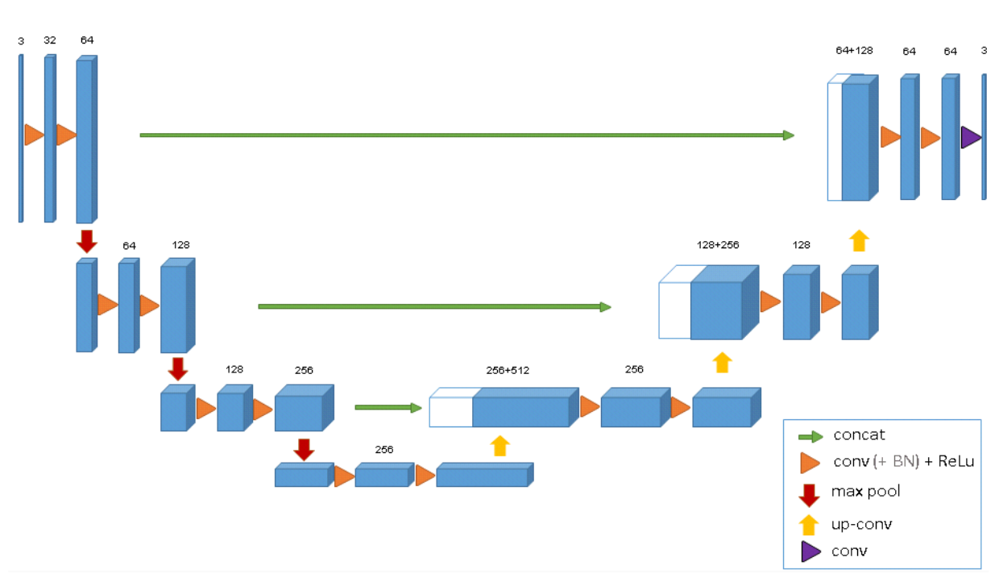

Архитектура unet может быть разделена на левую (уменьшающую размерность картинки) и правую (увеличивающую) части.   
Левая часть - это сверточная сеть. Два 3х3 сверточных слоя следуют за активационной функцией Relu последовательно(Sequentially) и после этого применяется 2x2 maxpool слой (на картинке красная стрелка).   
В это время правая часть - то место где происходят действительно интересные вещи. Правая часть также имеет два 3х3 сверточных слоя, соединенные вместе (Sequentially), но нет привычных нам Relu активационной функции и MaxPool слоя. Вместо них зеленая стрелка на изображении. Проходя по расширяющему пути, мы будем брать изображение (копию) из левой части и комбинировать с изображением из правой (серая стрелка на изображении). Помните, что последовательные 3х3 сверточные слои также используются в правой части. Поэтому вход для них будет комбинацией с изображения из левой части и прошлого слоя (комбинация половин белой и голубой коробки в левой части изображения). Итог работы нейронной сети - это выходная сегментационная карта.

Особенность U-net - skip connection, похожие на те, что помогли решить проблему исчезающего градиента в задача классификации (ResNet архитектура). Данные skip connections позволяют сигналу не только проходить строго, сначала по нисходящей лестницы слоев, а потом по восходящей лестнице апсемплинга(увеличение маленькой репрезентации изображения в полноценную карту), но и также перескакивать между слоями одного уровня, что в частности решает проблему дублирования функций слоев и улучшает эффективность обучения.


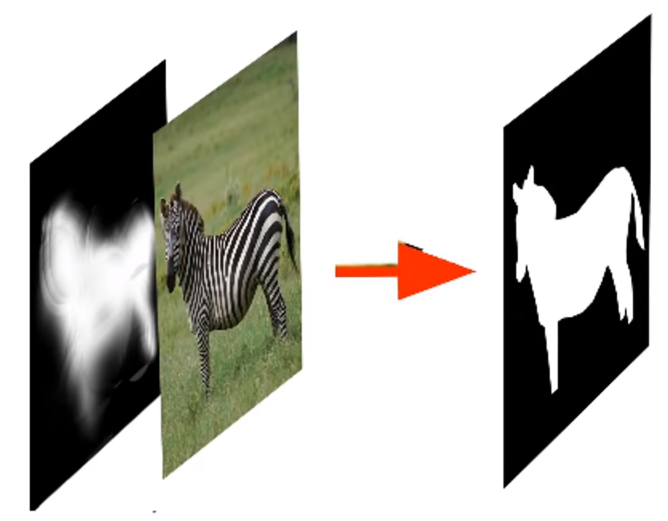


### LinkNet
[Статья](https://arxiv.org/abs/1707.03718).

В этой архитектуре левая часть тоже не отличается от Unet. А в правой части вместо конкатенации идет суммирование, чтобы уменьшать количество обучаемых параметров. Из-за меньшего количества параметров данные нейронная сеть будет лучше справлять с real-time сегментацией.

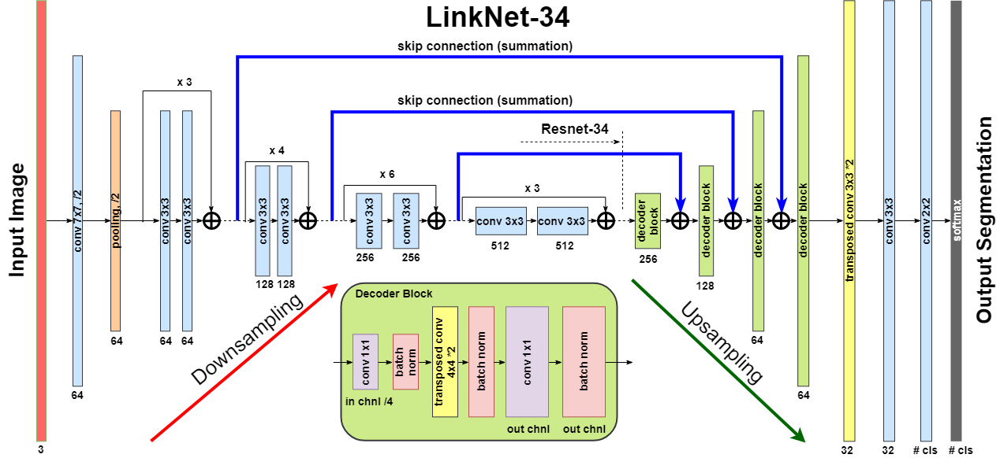


### PSPNet
[GitHub. Pyramid Scene Parsing Network](https://github.com/Lextal/pspnet-pytorch)   
[Статья](https://arxiv.org/abs/1612.01105)


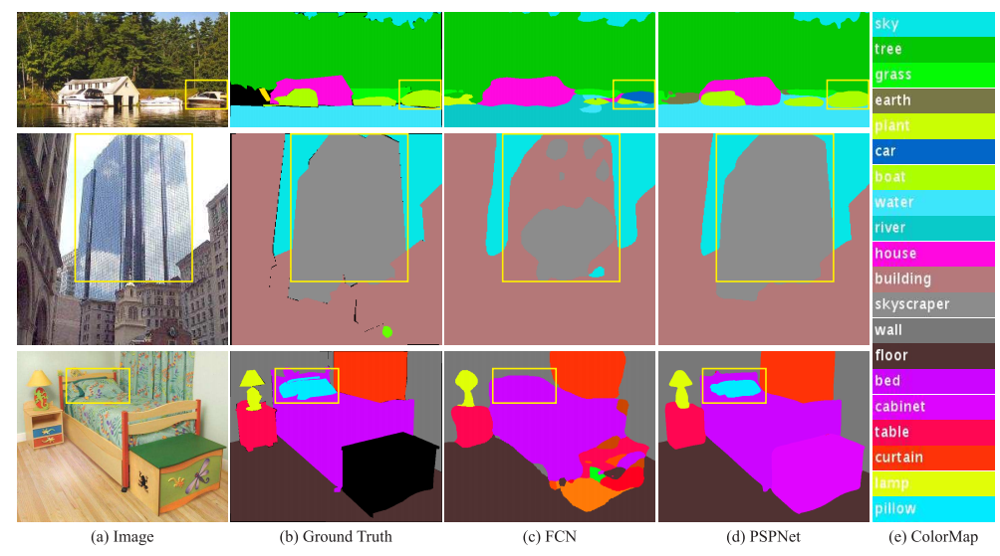



**Вопрос:** Почему у FCN не получается делать качественную сегментацию?


На изображении сравнение работы FCN и PSPNet, некоторые объекты сегментируются правильно, но относятся к неправильному классу. Это происходит из-за того, что у FCN недостаточно контекста картинки, чтобы понять, что перед ней лодка, а не машина, но глядя на контекст вокруге, можно понять, что если объект находится на воде, то вероятней всего это не машина, а лодка.


До этого брали один вектор, который вышел из энкодера и растягиваем его до размера исходной картинки, чтобы получить маску, теперь можем поделить карту с признаками на несколько регионов разных масштабов путем прохода через слой пулинга (в статье предлагают регионы масштабов 1x1, 2x2, 3x3 и 6x6), далее эти тензоры пропускаем через один слой свертки 1х1 для сжатия каналов, а затем сконкатенируем эти выходы с картой признаков (перед этим прогнав через слой апсемлинга, чтобы были одинаковые размерности) и сделаем привычную операцию деконволюций для получения маски.



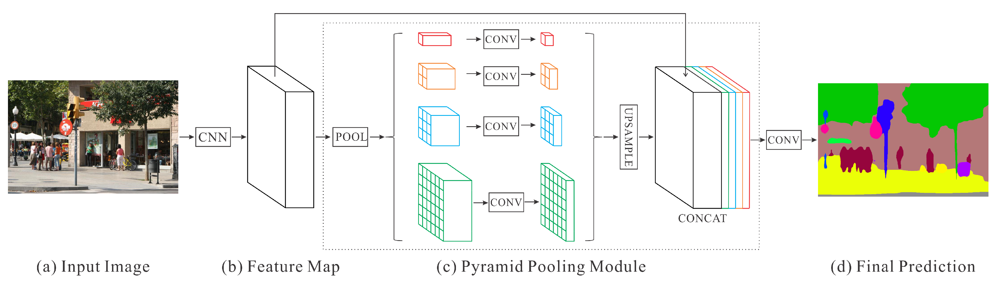


### FPN
[Feature Pyramid Network](https://arxiv.org/abs/1901.02446)
В этой нейронной сети маски предсказываются не с последнего уровня, а с каждого, тем самым можно находить объекты разных масштабов с разных карт признаков.



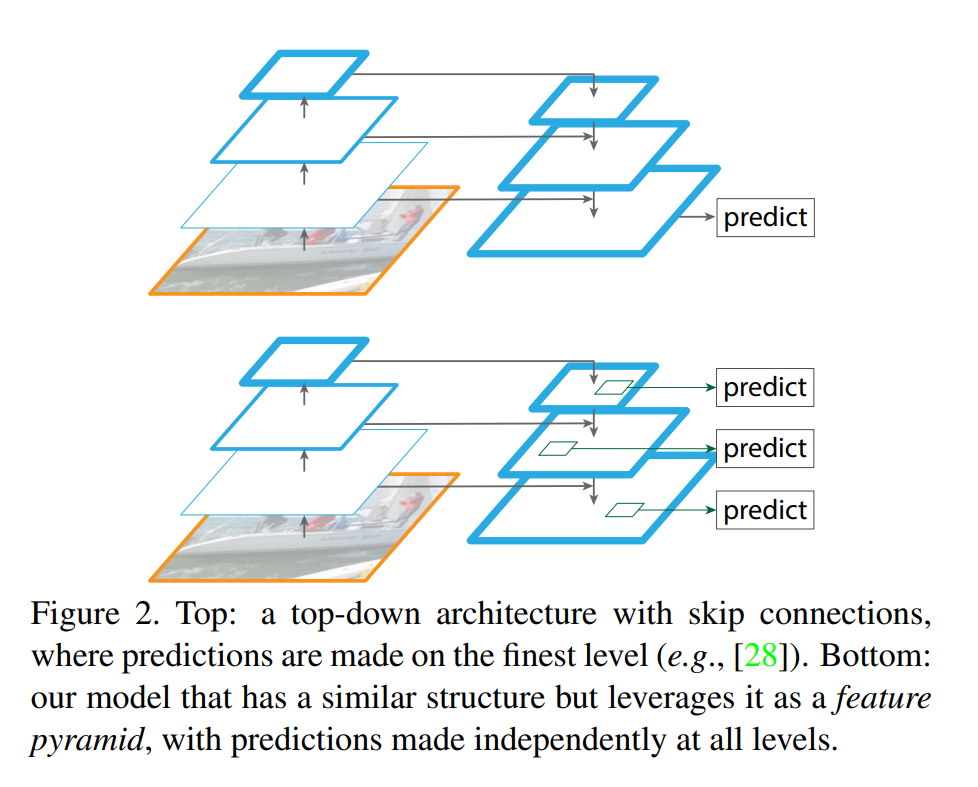

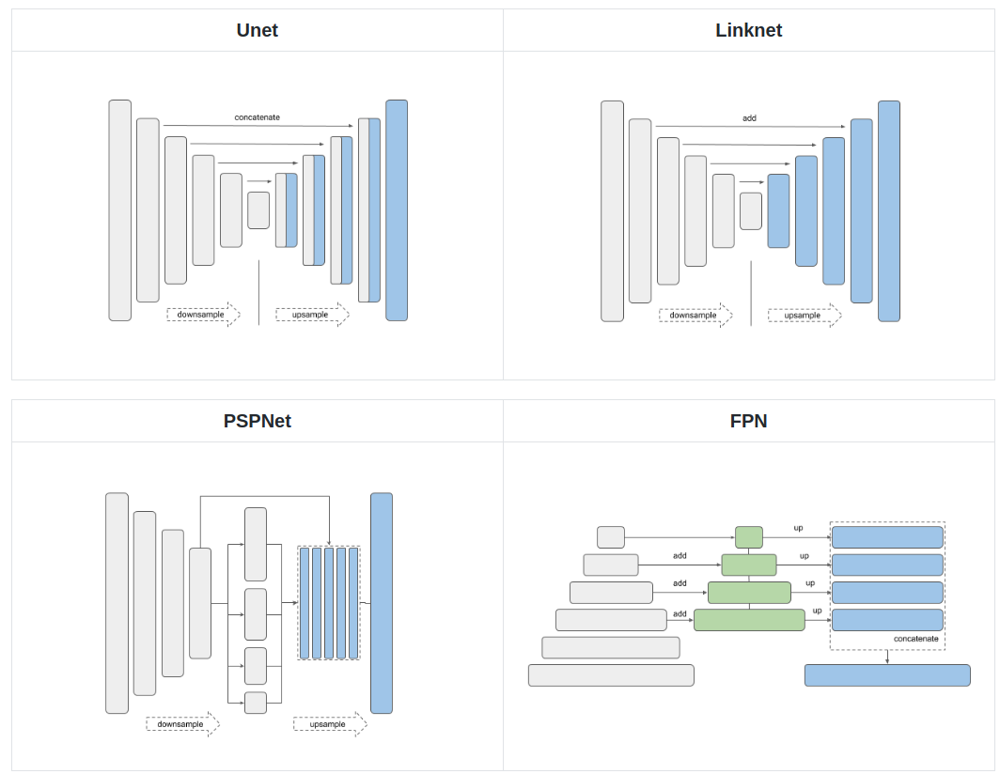

## Оценка качества

нужна какая-то оценка качества моделей.

Обычно в задачах, решаемых с помощью нейронных сетей, настройка процесса обучения основывается большей частью на опыте исследователя и некоторых эвристиках. Например, для задач сегментации изображений чаще всего применяются функции потерь, основанные на оценке совпадения форм распознанных зон, так называемые Intersection over Union.

Интуитивно, основываясь на понимании поведения и результатах исследований, такого рода функции дадут лучший результат, чем те, которые не заточены под изображения, как например кросс-энтропийные. Тем не менее, эксперименты в поисках оптимального варианта для такого типа задач в целом и каждой задачи индивидуально продолжаются.

### Коэффициент DICE

* Dice может использоваться для попиксельного сравнения между предсказанной маской и истинной маской
* Dice - это площадь пересечения дважды, деленная на общее количество пикселей на двух картинках


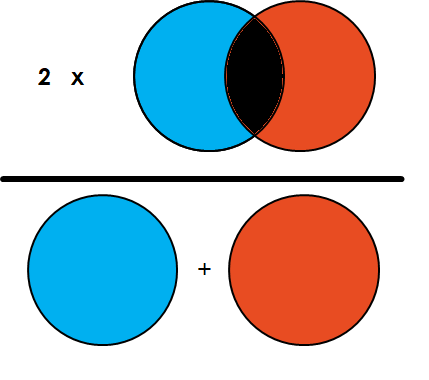



Формула подсчета:

<center> $ \huge \frac{2*|X∩Y|}{|X|+|Y|}$ </center>

<br>

где X - это предсказанное множество пикселей, а Y - истина.

### Intersection over Union

IoU - это мера величины перекрытия между двумя масками. Он вычисляет размер перекрытия между двумя объектами, деленный на общую площадь объединенных объектов.



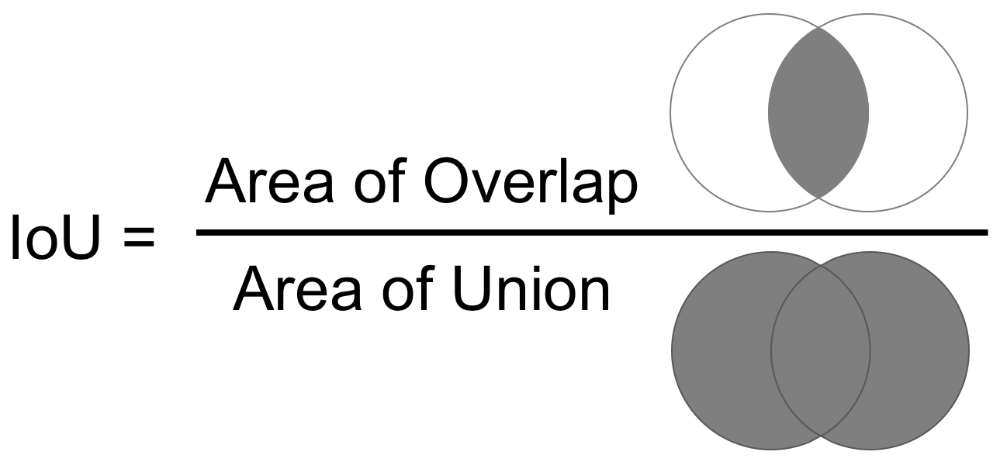

Формула подсчета:

<center> $ \huge \frac{|X∩Y|}{|X∪Y|}$ </center>

<br>

где X - это предсказанное множество пикселей, а Y - истина.

#<h1><center>Практическая часть</center></h1>

pip install segmentation-models-pytorch

### обучение с пакетом segmentation-models-pytorch [https://pypi.org/project/segmentation-models-pytorch/]
модели с разной архитектурой и энкодерами:

In [11]:
import segmentation_models_pytorch as smp

model = smp.Unet('resnet18', classes=1, activation='softmax')

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [12]:
from segmentation_models_pytorch.encoders import get_preprocessing_fn

preprocess_input = get_preprocessing_fn('resnet18', pretrained='imagenet')

In [13]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

In [22]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

def load_oxford_pet_segmentation(data_dir='./data', batch_size=4, image_size=224):
    """
    Загрузка датасета Oxford-IIIT Pet для задачи сегментации
    """

    # Трансформации для изображений и масок
    image_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    mask_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.PILToTensor()
    ])

    # Загружаем датасет с сегментационными масками
    train_dataset = torchvision.datasets.OxfordIIITPet(
        root=data_dir,
        split='trainval',
        target_types='segmentation',
        download=True,
        transform=image_transform,
        target_transform=mask_transform
    )

    test_dataset = torchvision.datasets.OxfordIIITPet(
        root=data_dir,
        split='test',
        target_types='segmentation',
        download=True,
        transform=image_transform,
        target_transform=mask_transform
    )

    # Функция для коллации батча (обработка масок)
    def collate_fn(batch):
        images = []
        masks = []
        for image, mask in batch:
            images.append(image)
            # Преобразуем маску: оставляем только первый канал и нормализуем
            mask = mask[0].unsqueeze(0)  # [1, H, W]
            mask = (mask != 2).float()   # 1 - пиксель животного, 0 - фон
            masks.append(mask)

        return torch.stack(images), torch.stack(masks)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    return train_loader, test_loader, train_dataset, test_dataset

In [23]:
train_loader, test_loader, train_dataset, test_dataset = load_oxford_pet_segmentation(data_dir='./data', batch_size=4, image_size=224)

In [24]:
def visualize_dataset(dataset, num_samples=8):
    """
    Визуализация примеров из датасета
    """
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.ravel()

    for i in range(num_samples):
        image, target = dataset[i]

        # Денормализация изображения
        image = image.numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].set_title(f'Class: {target}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def visualize_segmentation(dataset, num_samples=4):
    """
    Визуализация изображений и масок сегментации
    """
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))

    for i in range(num_samples):
        image, mask = dataset[i]

        # Денормализация изображения
        image_display = image.numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_display = std * image_display + mean
        image_display = np.clip(image_display, 0, 1)

        # Отображение изображения
        axes[i, 0].imshow(image_display)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        # Отображение маски
        mask_display = mask[0].numpy()  # Берем первый канал
        axes[i, 1].imshow(mask_display, cmap='gray')
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

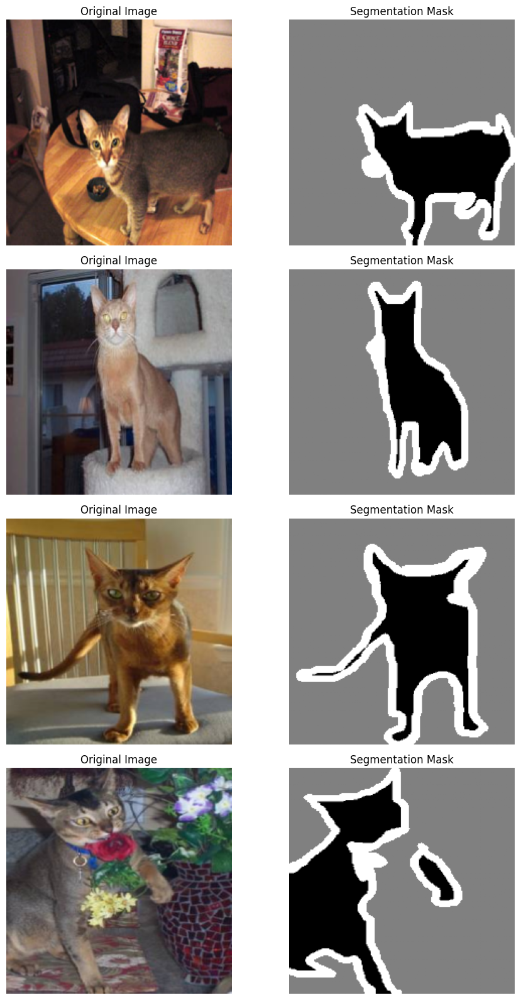

In [25]:
visualize_segmentation(test_dataset, num_samples=4)

In [26]:
EPOCHS = 10
T_MAX = EPOCHS * len(train_loader)
OUT_CLASSES = 1

In [27]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for batch_idx, (images, masks) in enumerate(dataloader):
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape, masks.shape)
        loss = loss_fn(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        print(end=".")
        #

    return total_loss / len(dataloader)

def validate_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            # print(outputs.shape, masks.shape)
            loss = loss_fn(outputs, masks)
            total_loss += loss.item()


    return total_loss / len(dataloader)

In [28]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler,
                epochs, device, save_path='best_model.pth'):
    """
    Complete training cycle
    """
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 50)

        # Training phase
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
        train_losses.append(train_loss)

        # Validation phase
        val_loss = validate_epoch(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
            }, save_path)
            print(f'Best model saved with val_loss: {val_loss:.4f}')

        print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.2e}')
        print()

    return train_losses, val_losses

In [29]:
loss_fn = smp.losses.DiceLoss(mode='multilabel')

# Optimizer, scheduler
optimizer = torch.optim.Adam([
    {'params': model.decoder.parameters(), 'lr': 1e-4},
    {'params': model.encoder.parameters(), 'lr': 1e-5},
])
device = "cuda" if torch.cuda.is_available() else "cpu"
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

train_losses, val_losses = train_model(
        model=model.to(device),
        train_loader=train_loader,  #
        val_loader=test_loader,      #
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=5,
        device=device,
        save_path='best_segmentation_model.pth'
    )

Epoch 1/5
--------------------------------------------------


D:\Iterpretators\Python3.11\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................Best model saved with val_loss: 0.4778
Train Loss: 0.4827, Val Loss: 0.4778
Curr

### Задание 1.

    1.1. Собрать вариант модели сегментации из архитектур : UNet, FPN, Linknet, ... (https://github.com/qubvel-org/segmentation_models.pytorch/tree/main#-models-and-encoders-)

    1.2. выбрать один из энкодеров : https://smp.readthedocs.io/en/latest/encoders.html
    1.3. установить параметры модели соответствующие набору данных
    1.4. провести обучение (5-6 эпох убедиться , что обучение идет)
    1.5. Визуализировать результат


## Обучение на платформе Ultralytics

https://docs.ultralytics.com/ru/tasks/segment/



Модель создана: Unet с энкодером resnet18

Начинаем обучение (5-6 эпох)...
Epoch 1/6 | Train Loss: 0.4624 | Validation Loss: 0.4496
Epoch 2/6 | Train Loss: 0.4580 | Validation Loss: 0.4523
Epoch 3/6 | Train Loss: 0.4531 | Validation Loss: 0.4518
Epoch 4/6 | Train Loss: 0.4485 | Validation Loss: 0.4486
Epoch 5/6 | Train Loss: 0.4446 | Validation Loss: 0.4477
Epoch 6/6 | Train Loss: 0.4423 | Validation Loss: 0.4432
Обучение завершено.

Визуализация результатов на примере из валидационной выборки...


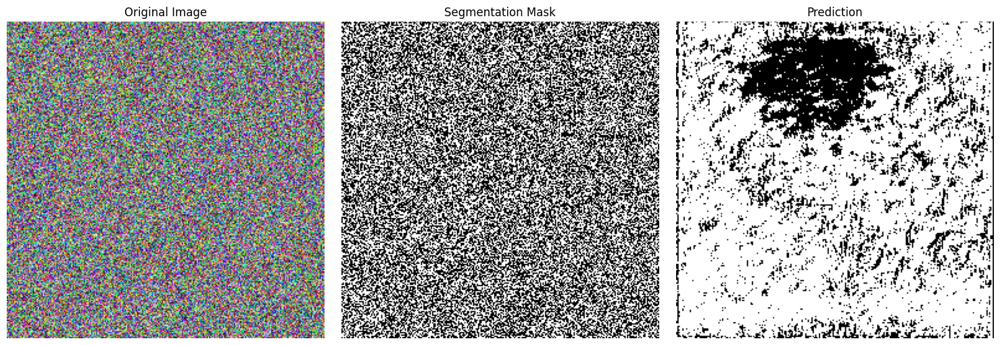

In [32]:
# Установка необходимой библиотеки
# !pip install segmentation-models-pytorch
# !pip install torch torchvision torchaudio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import os
from torchvision.transforms import functional as F
from PIL import Image

# ====================================================================
# 1.1. 1.2. 1.3. Собрать модель и установить параметры
# ====================================================================

# 1.1. Архитектура: UNet
# 1.2. Энкодер: resnet34 (с предобученными весами)
# 1.3. Параметры:
ENCODER = 'resnet18'
ENCODER_WEIGHTS = 'imagenet'
NUM_CLASSES = 1  # Для бинарной сегментации (объект / фон)
ACTIVATION = 'sigmoid' # 'sigmoid' для бинарной сегментации

# Определение модели
model = smp.Unet(
    encoder_name=ENCODER,        # Выбранный энкодер
    encoder_weights=ENCODER_WEIGHTS, # Использование предобученных весов ImageNet
    in_channels=3,               # 3 канала для RGB изображения
    classes=NUM_CLASSES,         # Количество классов
    activation=ACTIVATION,       # Активация на выходе (Sigmoid для бинарной сегментации)
)

print(f"Модель создана: {model.__class__.__name__} с энкодером {ENCODER}")

# ====================================================================
# Вспомогательные функции и настройка данных (Адаптация существующих)
#
# ВНИМАНИЕ: Для запуска требуется, чтобы существовали классы
# SegmentationDataset и DATA_TRANSFORMS из вашего ноутбука.
# Поскольку их нет в предоставленных сниппетах, я создаю заглушки
# для демонстрации функционала. В реальной работе используйте ваши классы.
# ====================================================================

# Настройки нормализации (стандартные для ImageNet, если используются веса 'imagenet')
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

class DummySegmentationDataset(Dataset):
    """
    Заглушка для класса Dataset.
    Генерирует 10 пар синтетических изображений и масок (256x256)
    для проверки работы тренировочного цикла.
    """
    def __init__(self, size=10, img_shape=(3, 256, 256)):
        self.size = size
        self.img_shape = img_shape

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Синтетическое изображение (случайные нормализованные данные)
        image = np.random.rand(*self.img_shape).astype(np.float32)
        
        # ИСПРАВЛЕНИЕ: Генерируем int (0 или 1), а затем преобразуем в float32.
        mask = np.random.randint(0, 2, size=(1, self.img_shape[1], self.img_shape[2])).astype(np.float32)

        # Выполняем обратную нормализацию только для имитации
        # работы с нормализованными входными данными модели
        # (На самом деле, здесь должна быть прямая нормализация, но
        # в заглушке мы имитируем уже нормализованные данные)
        for i in range(self.img_shape[0]):
            image[i] = (image[i] - MEAN[i]) / STD[i]

        return torch.tensor(image, dtype=torch.float), torch.tensor(mask, dtype=torch.float)


# 4. Visualization Function (Adapted from Snippet 5)
def denormalize(x: np.array, mean: np.array, std: np.array) -> np.array:
    """Обратная нормализация для отображения изображения."""
    x_denorm = x.copy()
    for i in range(x_denorm.shape[0]):
        x_denorm[i] = x_denorm[i] * std[i] + mean[i]
    return np.clip(x_denorm, 0, 1)

def show_images_and_masks(images, masks, predictions=None, max_images=3):
    """
    Визуализация исходных изображений, масок и (опционально) предсказаний.
    Адаптировано из функции в ноутбуке.
    """
    num_rows = min(len(images), max_images)
    num_cols = 2 if predictions is None else 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))

    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(num_rows):
        # 1. Исходное изображение
        image_np = images[i].cpu().numpy()
        image_display = denormalize(image_np, MEAN, STD)
        image_display = np.transpose(image_display, (1, 2, 0)) # C, H, W -> H, W, C

        axes[i, 0].imshow(image_display)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        # 2. Маска
        mask_np = masks[i][0].cpu().numpy() # Берем первый канал
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

        # 3. Предсказание
        if predictions is not None:
            pred_np = predictions[i][0].cpu().numpy()
            axes[i, 2].imshow(pred_np, cmap='gray')
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Создание DataLoader'ов с заглушкой
BATCH_SIZE = 8
train_dataset = DummySegmentationDataset(size=50)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataset = DummySegmentationDataset(size=10)
valid_dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=False)

# ====================================================================
# 1.4. Проведение обучения (5-6 эпох)
# ====================================================================

# Определение устройства
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)

# Функции потерь и оптимизатор
# Использование комбинации Dice Loss и BCE Loss (Binary Cross Entropy)
loss_function = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

NUM_EPOCHS = 6 # 5-6 эпох для проверки

def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    """Функция для тренировки одной эпохи."""
    model.train()
    total_loss = 0
    for images, masks in dataloader:
        images, masks = images.to(device), masks.to(device)

        # Прямой проход
        optimizer.zero_grad()
        predictions = model(images)

        # Расчет потерь
        loss = loss_fn(predictions, masks)

        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(dataloader.dataset)

def validate_one_epoch(model, dataloader, loss_fn, device):
    """Функция для валидации одной эпохи."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)

            predictions = model(images)
            loss = loss_fn(predictions, masks)

            total_loss += loss.item() * images.size(0)
    return total_loss / len(dataloader.dataset)

print("\nНачинаем обучение (5-6 эпох)...")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_dataloader, loss_function, optimizer, DEVICE)
    val_loss = validate_one_epoch(model, valid_dataloader, loss_function, DEVICE)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")

print("Обучение завершено.")

# ====================================================================
# 1.5. Визуализация результата
# ====================================================================

print("\nВизуализация результатов на примере из валидационной выборки...")

# Получаем пакет данных для визуализации
images, masks = next(iter(valid_dataloader))
images, masks = images.to(DEVICE), masks.to(DEVICE)

# Получаем предсказания
with torch.no_grad():
    model.eval()
    predictions = model(images)

# Применяем пороговое значение для бинарной маски (0.5)
# Sigmoid уже был применен моделью, поэтому значения находятся в диапазоне [0, 1]
predicted_masks = (predictions > 0.5).float()

# Визуализируем
# Используем images, masks, и predicted_masks для функции show_images_and_masks
show_images_and_masks(images, masks, predicted_masks, max_images=3)

# ====================================================================
# Дополнительная визуализация структуры модели
# ====================================================================
# Вы можете посмотреть структуру модели, чтобы убедиться, что она корректно создана
# print("\nСтруктура модели UNet с энкодером ResNet34:")
# print(model)

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.3 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.1/112.6 GB disk)


In [3]:
from ultralytics import YOLO
from ultralytics import settings
# Load a model
model = YOLO("yolo11n-seg.pt")  # load a pretrained model (recommended for training)


# Update a setting
settings.update({"runs_dir": "/runs"})

# Update multiple settings
settings.update({"runs_dir": "/runs", "tensorboard": False})

# Reset settings to default values
settings.reset()
# Train the model
results = model.train(data="package-seg.yaml", epochs=2, imgsz=640, batch=16, workers=6)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=package-seg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pret

In [4]:
# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    xy = result.masks.xy  # mask in polygon format
    xyn = result.masks.xyn  # normalized
    masks = result.masks.data  # mask in matrix format (num_objects x H x W)


image 1/1 /content/bus.jpg: 640x480 6 packages, 60.4ms
Speed: 2.3ms preprocess, 60.4ms inference, 10.7ms postprocess per image at shape (1, 3, 640, 480)


In [5]:
from PIL import Image
import numpy as np

In [6]:
result.orig_img.shape

(1080, 810, 3)

In [7]:
result.masks.data.detach().cpu().numpy().shape

(6, 640, 480)

In [8]:
masks = result.masks.data.detach().cpu().numpy().astype(np.uint8)

/tmp/ipython-input-721312040.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((masks[ i, :,:]*255).astype(np.uint8), mode='1').resize([512,512])


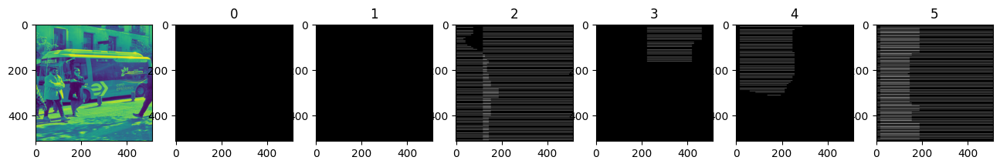

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline


fig, ax = plt.subplots(1, 7, figsize=(16, 3))
im = Image.fromarray(result.orig_img).convert("L").resize([512,512])
ax[0].imshow(im)

for i in range(0, 6):
    im = Image.fromarray((masks[ i, :,:]*255).astype(np.uint8), mode='1').resize([512,512])
    # Image.fromarray(masks[5, :,:].astype(np.uint8), mode='1').resize([512,512])
    ax[i+1].imshow(im)
    ax[1+i].set_title(str(i))
plt.show()

### Задание 2.

    2.1. Собрать вариант модели сегментации для одного из набора примеров: (https://docs.ultralytics.com/ru/datasets/segment/package-seg/, https://docs.ultralytics.com/ru/datasets/segment/carparts-seg/, https://docs.ultralytics.com/ru/datasets/segment/crack-seg/)

    2.2. выбрать один из энкодеров : https://docs.ultralytics.com/ru/tasks/segment/#models
    2.3. установить параметры модели соответствующие набору данных
    2.4. провести обучение (5-6 эпох убедиться , что обучение идет)
    2.5. Визуализировать результат

## Дополнительные материалы

1. [Handwritten Text Segmentation](https://arxiv.org/pdf/1906.05229.pdf)
2. [Сегментация медицинских изображений](https://arxiv.org/abs/1505.04597)
3. [Рекуррентные нейронные сети для семантической обработки](https://imatge-upc.github.io/rsis/)
4. [Pyramid Scene Parsing Network](https://github.com/Lextal/pspnet-pytorch)
5. [Pyramid Scene Parsing Network | Lecture 32 (Part 3) | Applied Deep Learning](https://youtu.be/6fjsJT4gYnI)
6. [DeepLabV3](https://arxiv.org/abs/1706.05587)
7. [DeepLabv3+ | Lecture 32 (Part 4) | Applied Deep Learning](https://youtu.be/Gzrej8ciK9o)
8. [Mask-RCNN](https://kharshit.github.io/blog/2019/08/23/quick-intro-to-instance-segmentation)
9. [LinkNet](https://arxiv.org/abs/1707.03718)
10. [Feature Pyramid Network](https://arxiv.org/abs/1901.02446)
11. [Semantic Segmentation Benchmarks](https://paperswithcode.com/task/semantic-segmentation)

